<a href="https://colab.research.google.com/github/re1nsilitonga/Algorithm-and-Programming-2/blob/main/SPT_13524029_13524093.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas Besar IF2120 Probabilitas dan Statistika 2025/2026**

### Topik : **Car**


K01 & K02 - Kelompok 10

Anggota Kelompok :
1. Niko Samuel Simanjuntak 13524029
2. Reinsen Silitonga - 13524093

## Petunjuk
1. Silahkan **buat salinan** template notebook ini untuk mengerjakan.
2. Kalian dapat menambahkan blok code atau blok markdown baru jika diperlukan.
3. Selamat mengerjakan! 😸

## Inisialisasi Dependencies dan Load Data

Import required libraries

In [ ]:
# Sesuaikan dengan kebutuhan, uncomment yang perlu, hapus yang ga perlu, dan tambahkan jika perlu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Data

In [ ]:
import gdown

# Ambil file_id dari link gdrive dataset
# https://drive.google.com/file/d/1-hmbmqJrGxOLbgbKckkgLj7uQ96HSzNy/view?usp=drive_link -> file_id = 1-hmbmqJrGxOLbgbKckkgLj7uQ96HSzNy

# Kemudian, masukan file_id dengan template url berikut
# https://drive.google.com/uc?id={file_id}

url = "https://drive.google.com/uc?id=1-hmbmqJrGxOLbgbKckkgLj7uQ96HSzNy"

output = "car.csv"
gdown.download(url, output, quiet=False)

data = pd.read_csv(output)
data.info()

Downloading...
From: https://drive.google.com/uc?id=1-hmbmqJrGxOLbgbKckkgLj7uQ96HSzNy
To: /content/car.csv
100%|██████████| 575k/575k [00:00<00:00, 11.5MB/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              2500 non-null   object 
 1   Make                   2500 non-null   object 
 2   Segment                2500 non-null   object 
 3   Fuel_Type              2500 non-null   object 
 4   Speed_kmh              2500 non-null   float64
 5   Fuel_Efficiency_kmpl   2500 non-null   float64
 6   Engine_Temp_C          2500 non-null   float64
 7   Tire_Pressure_psi      2500 non-null   float64
 8   Emissions_CO2_gpkm     2500 non-null   float64
 9   Cabin_Humidity_pct     2500 non-null   float64
 10  Engine_Load_Index      2500 non-null   float64
 11  Fuel_Level_pct         2500 non-null   float64
 12  Air_Intake_gps         2500 non-null   float64
 13  Cabin_Air_Quality_AQI  2500 non-null   float64
dtypes: float64(10), object(4)
memory usage: 273.6+ KB


# Soal General

## Nomor 1
Menulis deskripsi statistika (Descriptive Statistics) dari semua kolom pada data.
- Data yang bersifat numerik dapat diberikan nilai mean, median, modus, standar deviasi, variansi, range, nilai minimum, maksimum, kuartil, IQR, skewness dan kurtosis.
- Data yang bersifat kategorikal dapat dicari unique values, dan proporsi nya.

### Implementasi Menggunakan Fungsi Buatan Sendiri

Data Numerik

In [ ]:
# Tulis kode deskripsi statistika data numerik kalian disini

def rata2(numcol):
  return sum(numcol)/len(numcol)

def nilai_tengah(numcol):
  n = len(numcol)
  sorted_numcol = sorted(numcol)
  if n % 2 == 1:
    return sorted_numcol[n//2]
  else:
    return (sorted_numcol[(n//2)-1] + sorted_numcol[n//2])/2

def modus(numcol):
  counts = {}
  mode = []

  for value in numcol:
    if value not in counts:
      counts[value] = 1
    else:
      counts[value] += 1

  max_count = 0
  for key in counts:
    if counts[key] > max_count:
      max_count = counts[key]

  for key in counts:
    if counts[key] == max_count:
      mode.append(key)

  return mode

def standar_deviasi(numcol):
  return np.sqrt(variansi(numcol))

def variansi(numcol):
  n = len(numcol)
  mean = rata2(numcol)
  varians = 0
  for value in numcol:
    varians += (value - mean)**2
  return varians/n

def rentang(numcol):
  return max(numcol) - min(numcol)

def nilai_minimum(numcol):
  return min(numcol)

def nilai_maksimum(numcol):
  return max(numcol)

def kuartil(numcol):
  n = len(numcol)
  sorted_numcol = sorted(numcol)
  Q1 = nilai_tengah(sorted_numcol[:n//2])
  Q3 = nilai_tengah(sorted_numcol[n//2:])
  Q2 = nilai_tengah(numcol)
  Q4 = nilai_maksimum(numcol)
  return Q1, Q2, Q3, Q4

def IQR(numcol):
  Q1, Q2, Q3, Q4 = kuartil(numcol)
  return Q3 - Q1

def skewness(numcol):
  n = len(numcol)
  mean = rata2(numcol)
  sd = standar_deviasi(numcol)

  if sd == 0:
    return 0

  jumlah = 0
  for value in numcol:
    jumlah += (value - mean)**3

  return (jumlah / n) / (sd**3)

def kurtosis(numcol):
  n = len(numcol)
  mean = rata2(numcol)
  sd = standar_deviasi(numcol)

  if sd == 0:
    return 0

  jumlah = 0
  for value in numcol:
    jumlah += (value - mean)**4

  return (jumlah / n) / (sd**4)


def deskripsi_data_numerik(df):
  numcols = df.select_dtypes(include=['number']).columns
  for col in numcols:
    numcol = df[col]
    print(f"\nKolom {col}")
    print(f"Jumlah data       : {len(numcol)}")
    print(f"Rata-rata         : {rata2(numcol)}")
    print(f"Median            : {nilai_tengah(list(numcol))}")
    print(f"Modus             : {modus(numcol)}")
    print(f"Variansi          : {variansi(numcol)}")
    print(f"Standar deviasi   : {standar_deviasi(numcol)}")
    print(f"Range             : {rentang(numcol)}")
    print(f"Nilai minimum     : {nilai_minimum(numcol)}")
    print(f"Nilai maksimum    : {nilai_maksimum(numcol)}")
    Q1, Q2, Q3, Q4 = kuartil(numcol)
    print(f"Q1                : {Q1}")
    print(f"Q2 (Median)       : {Q2}")
    print(f"Q3                : {Q3}")
    print(f"Q4 (Maksimum)     : {Q4}")
    print(f"IQR               : {IQR(numcol)}")
    print(f"Skewness          : {skewness(numcol)}")
    print(f"Kurtosis          : {kurtosis(numcol)}")
    print()

deskripsi_data_numerik(data)


Kolom Speed_kmh
Jumlah data       : 2500
Rata-rata         : 63.78396108296931
Median            : 53.429400049127395
Modus             : [75.350351684375, 42.86073533648835, 51.67065472728354, 34.1681155333395, 86.42145725285114, 49.458388752292464, 90.485970605448, 80.5947042178683, 46.68651367610195, 68.49108558025033, 99.22877031126576, 51.27680417874475, 38.510014795268425, 42.60444141062901, 84.53687086287329, 108.60176400013144, 43.703269479714, 43.78978968990436, 37.784309176599706, 25.575023090382302, 53.45273297042095, 109.5569395536, 54.6793194876499, 36.783191736949775, 56.53502849781544, 40.76098927667404, 54.38969468704792, 51.26877063529022, 46.80871111482433, 44.590824648049306, 55.74529790229931, 100.0411311875802, 28.162674323859516, 51.56898706319648, 40.13323677118403, 45.47298743128728, 109.1478995521669, 42.53081672510545, 41.36824441267184, 58.97844307031498, 71.22130983905214, 33.48773342492856, 90.43066027467896, 107.6416104514854, 44.32553441444818, 40.962965

Data Kategorikal

In [ ]:
# Tulis kode deskripsi statistika data kategorikal kalian disini

### Implementasi Menggunakan Library

#### Data Numerik

In [ ]:
# Tulis kode deskripsi statistika data numerik kalian disini

def deskripsi_data_numerik_library(df):
  numcols = df.select_dtypes(include=['number']).columns

  for col in numcols:
    numcol = df[col]
    print(f"\nKolom {col}")
    print(f"Jumlah data       : {numcol.count()}")
    print(f"Rata-rata         : {numcol.mean()}")
    print(f"Median            : {numcol.median()}")
    mode = numcol.mode().tolist()
    print(f"Modus             : {mode}")
    print(f"Variansi          : {numcol.var()}")
    print(f"Standar deviasi   : {numcol.std()}")
    print(f"Range             : {numcol.max() - numcol.min()}")
    print(f"Nilai minimum     : {numcol.min()}")
    print(f"Nilai maksimum    : {numcol.max()}")
    Q1 = numcol.quantile(0.25)
    Q2 = numcol.quantile(0.50)
    Q3 = numcol.quantile(0.75)
    Q4 = numcol.max()
    print(f"Q1                : {Q1}")
    print(f"Q2 (Median)       : {Q2}")
    print(f"Q3                : {Q3}")
    print(f"Q4 (Maksimum)     : {Q4}")
    IQR = Q3 - Q1
    print(f"IQR               : {IQR}")
    print(f"Skewness          : {numcol.skew()}")
    print(f"Kurtosis          : {numcol.kurtosis()}")
    print()

deskripsi_data_numerik_library(data)


Kolom Speed_kmh
Jumlah data       : 2500
Rata-rata         : 63.783961082969306
Median            : 53.429400049127395
Modus             : [6.633444515406303, 12.584861746708796, 13.614853337659603, 16.980884305121084, 17.547004463276153, 17.59573577965069, 17.77545859008061, 19.910428215049244, 20.0883859184854, 20.125432412938707, 20.41830569450981, 21.35144627208488, 21.455170773033977, 21.569608983481597, 22.442086689052523, 22.84177574979332, 22.970866467942813, 23.08021343720119, 23.37967700072561, 23.38696113697638, 23.435546229949672, 23.731665122007342, 24.276448183040017, 24.27864883903513, 24.351347223163582, 24.465134513441114, 24.55370996198732, 24.859367257622367, 24.982598325237383, 24.982939982744664, 25.01655032855374, 25.10053730178875, 25.19163529077366, 25.23178431052409, 25.27910973356182, 25.454069955167245, 25.575023090382302, 25.679348414800405, 25.74022181554899, 25.74432639667123, 25.888406747395123, 25.937633799106194, 26.195644559369185, 26.25107935952467, 

#### Data Kategorikal

In [ ]:
# Tulis kode deskripsi statistika data kategorikal kalian disini

#### Perbandingan Hasil Fungsi Buatan Sendiri dengan Library

Jelaskan apakah implementasi deskripsi statistika dengan menggunakan fungsi buatan sendiri dan menggunakan library menghasilkan nilai yang sama?

## Nomor 2
Apakah pada data tersebut terdapat outlier? Jika ya, dapatkah anda menanganinya? Jelaskan apa yang umumnya dilakukan untuk menangani outlier.

In [ ]:
# Tulis kode pengecekan outlier kalian disini

def cek_outlier(df):
  numcols = df.select_dtypes(include=['number']).columns

  for col in numcols:
    numcol = df[col]

    print(f"\nKolom {col}")

    Q1, Q2, Q3, Q4 = kuartil(numcol)
    iqr = IQR(numcol)
    batas_bawah = Q1 - 1.5 * iqr
    batas_atas = Q3 + 1.5 * iqr

    outlier = []

    for value in numcol:
      if value < batas_bawah or value > batas_atas:
        outlier.append(value)

    print(f"Batas bawah      : {batas_bawah}")
    print(f"Batas atas       : {batas_atas}")
    print(f"Jumlah outlier   : {len(outlier)}")
    print(f"Daftar outlier   : {outlier}")

cek_outlier(data)



Kolom Speed_kmh
Batas bawah      : -26.928420232002708
Batas atas       : 158.16413100740345
Jumlah outlier   : 0
Daftar outlier   : []

Kolom Fuel_Efficiency_kmpl
Batas bawah      : 2.936974159173456
Batas atas       : 25.84183380880675
Jumlah outlier   : 61
Daftar outlier   : [26.114272850338416, 26.095013146296814, 30.1748693476742, 29.42660468115668, 27.56970972858353, 26.98755364817293, 25.87990268552014, 28.42774703477981, 26.126926042965664, 27.34084345207333, 27.426584181528607, 29.613499203125947, 27.17903688430036, 26.843820158666347, 29.08761917654865, 30.007367710190717, 27.234920575365702, 29.45506028175368, 27.92669697176625, 29.4794556840334, 26.29652369105732, 27.81559547109096, 29.499345729317746, 26.88400277289953, 26.8024728835773, 28.275487140135752, 27.20436600190003, 28.102599408648786, 29.187824849225564, 26.70904577984083, 26.91046904033891, 27.30099040313621, 26.91226935064757, 26.98693509615084, 28.70814721214148, 31.04588938393113, 27.696065486182366, 25.895

Jelaskan hasil dan bagaimana cara kalian melakukan pengecekan outlier disini.

### Penanganan Outlier

Jelaskan metode yang Anda gunakan untuk menangani outlier pada bagian ini, beserta alasan pemilihan metode tersebut.

In [ ]:
# Tulis kode penanganan outlier kalian disini

def hitung_batas(numcol):
    Q1, _, Q3, _ = kuartil(numcol)
    IQR_val = Q3 - Q1
    lower = Q1 - 1.5 * IQR_val
    upper = Q3 + 1.5 * IQR_val
    return lower, upper

def winsorization(numcol):
    hasil = []
    lower, upper = hitung_batas(numcol)
    for i in numcol:
      if i < lower:
        hasil.append(lower)
      elif i > upper:
        hasil.append(upper)
      else:
        hasil.append(i)
    return hasil

def capping(numcol, lower=None, upper=None):
    hasil = []
    for x in numcol:
      if lower is not None and x < lower:
        hasil.append(lower)
      elif upper is not None and x > upper:
        hasil.append(upper)
      else:
        hasil.append(x)
    return hasil

def log_transform(numcol):
    hasil = []
    for x in numcol:
      if x <= 0:
        x = x + 1
      hasil.append(np.log(x))
    return hasil

def penanganan_outlier(df):
    df_clean = df.copy()

    # winsorization
    df_clean["Fuel_Efficiency_kmpl"] = winsorization(df_clean["Fuel_Efficiency_kmpl"])

    # capping
    lower_eng_temp, upper_eng_temp = hitung_batas(df_clean["Engine_Temp_C"])
    df_clean["Engine_Temp_C"] = capping(df_clean["Engine_Temp_C"],
                                        lower=lower_eng_temp,
                                        upper=upper_eng_temp)

    # winsorization
    df_clean["Tire_Pressure_psi"] = winsorization(df_clean["Tire_Pressure_psi"])
    lower_emisi, upper_emisi = hitung_batas(df_clean["Emissions_CO2_gpkm"])
    median_normal = nilai_tengah([x for x in df_clean["Emissions_CO2_gpkm"]
                                  if lower_emisi <= x <= upper_emisi])
    emisi_hasil = []
    for x in df_clean["Emissions_CO2_gpkm"]:
        if x < lower_emisi:
            emisi_hasil.append(lower_emisi)
        elif x > upper_emisi:
            emisi_hasil.append(upper_emisi)
        else:
            emisi_hasil.append(x)
    df_clean["Emissions_CO2_gpkm"] = emisi_hasil

    # capping batas atas
    lower_load, upper_load = hitung_batas(df_clean["Engine_Load_Index"])
    df_clean["Engine_Load_Index"] = capping(df_clean["Engine_Load_Index"],
                                            upper=upper_load)

    # winsorization
    df_clean["Air_Intake_gps"] = winsorization(df_clean["Air_Intake_gps"])

    # winsorization, tanpa negatif
    hasil_aqi = winsorization(df_clean["Cabin_Air_Quality_AQI"])
    df_clean["Cabin_Air_Quality_AQI"] = [max(0, x) for x in hasil_aqi]

    return df_clean

data_clean = penanganan_outlier(data)
cek_outlier(data_clean)



Kolom Speed_kmh
Batas bawah      : -26.928420232002708
Batas atas       : 158.16413100740345
Jumlah outlier   : 0
Daftar outlier   : []

Kolom Fuel_Efficiency_kmpl
Batas bawah      : 2.936974159173456
Batas atas       : 25.84183380880675
Jumlah outlier   : 0
Daftar outlier   : []

Kolom Engine_Temp_C
Batas bawah      : 78.13664874262261
Batas atas       : 112.10932764004886
Jumlah outlier   : 0
Daftar outlier   : []

Kolom Tire_Pressure_psi
Batas bawah      : 26.50650779766565
Batas atas       : 37.58518816243125
Jumlah outlier   : 0
Daftar outlier   : []

Kolom Emissions_CO2_gpkm
Batas bawah      : 29.549359218709398
Batas atas       : 250.9723381307336
Jumlah outlier   : 0
Daftar outlier   : []

Kolom Cabin_Humidity_pct
Batas bawah      : -19.68873583324534
Batas atas       : 127.11231375685742
Jumlah outlier   : 0
Daftar outlier   : []

Kolom Engine_Load_Index
Batas bawah      : -1.9968458072941437
Batas atas       : 6.218177542892914
Jumlah outlier   : 0
Daftar outlier   : []

Kol

## Nomor 3
Membuat Visualisasi plot distribusi. Berikan uraian penjelasan kondisi setiap kolom berdasarkan kedua plot tersebut. Jika numerik dapat dibuat dalam bentuk histogram dan box plot, dan jika kategorikal dengan histogram.

### Kolom Speed_kmh

Jelaskan kondisi kolom Speed_kmh berdasarkan hasil plot distribusi disini.

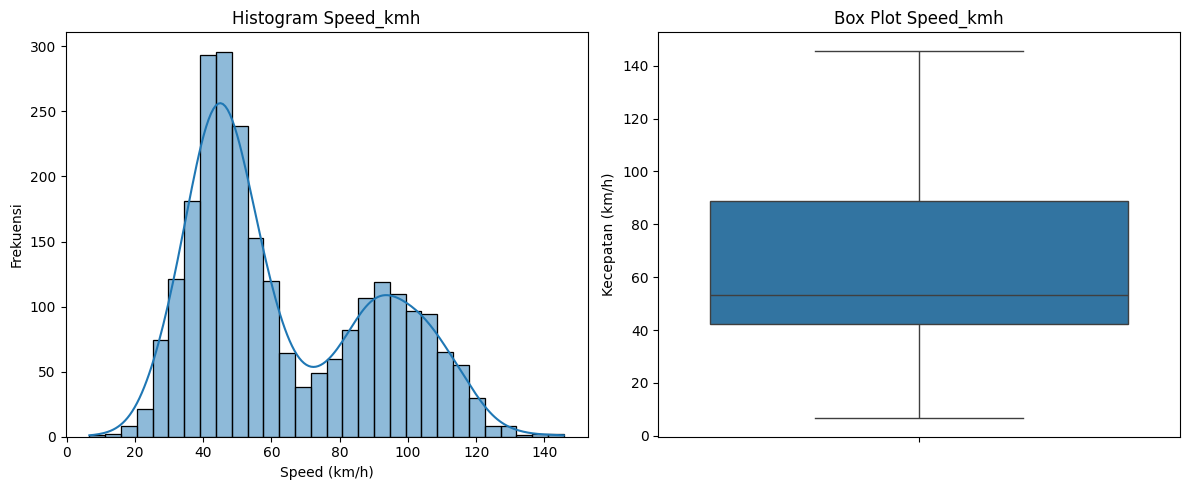

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Speed_kmh'], kde=True, bins=30)
plt.title('Histogram Speed_kmh')
plt.xlabel('Speed (km/h)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Speed_kmh'])
plt.title('Box Plot Speed_kmh')
plt.ylabel('Speed (km/h)')

plt.tight_layout()
plt.show()

### Kolom Fuel_Efficiency_kmpl

Jelaskan kondisi kolom Fuel_Efficiency_kmpl berdasarkan hasil plot distribusi disini.

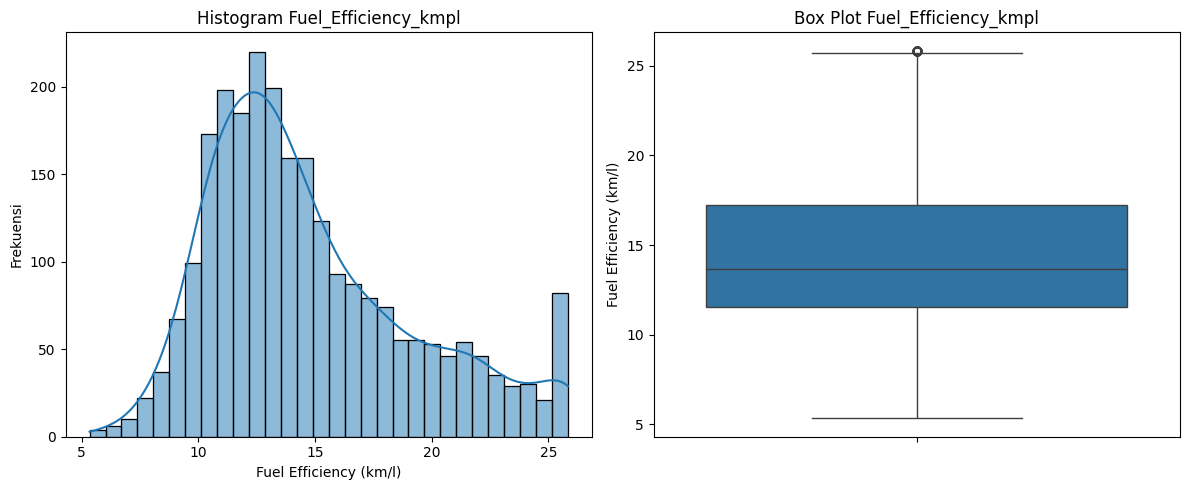

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Fuel_Efficiency_kmpl'], kde=True, bins=30)
plt.title('Histogram Fuel_Efficiency_kmpl')
plt.xlabel('Fuel Efficiency (km/l)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Fuel_Efficiency_kmpl'])
plt.title('Box Plot Fuel_Efficiency_kmpl')
plt.ylabel('Fuel Efficiency (km/l)')

plt.tight_layout()
plt.show()

### Kolom Engine_Temp_C

Jelaskan kondisi kolom Engine_Temp_C berdasarkan hasil plot distribusi disini.

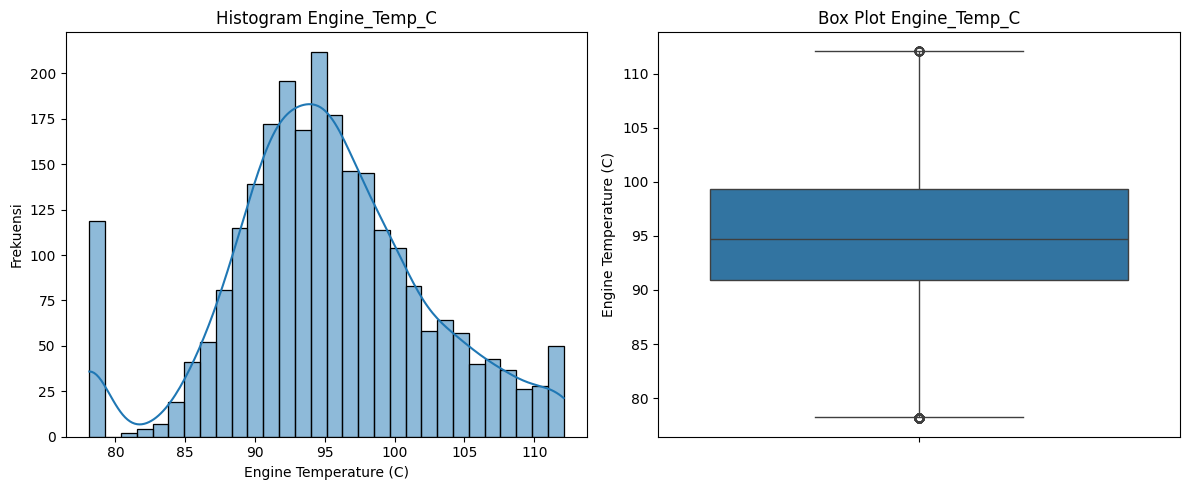

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Engine_Temp_C'], kde=True, bins=30)
plt.title('Histogram Engine_Temp_C')
plt.xlabel('Engine Temperature (C)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Engine_Temp_C'])
plt.title('Box Plot Engine_Temp_C')
plt.ylabel('Engine Temperature (C)')

plt.tight_layout()
plt.show()

### Kolom Tire_Pressure_psi

Jelaskan kondisi kolom Tire_Pressure_psi berdasarkan hasil plot distribusi disini.

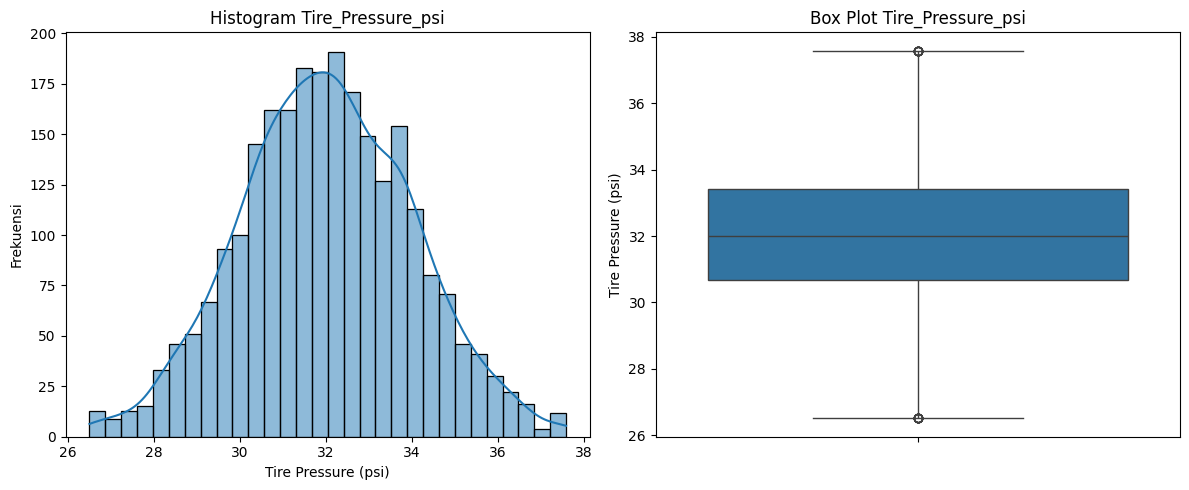

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Tire_Pressure_psi'], kde=True, bins=30)
plt.title('Histogram Tire_Pressure_psi')
plt.xlabel('Tire Pressure (psi)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Tire_Pressure_psi'])
plt.title('Box Plot Tire_Pressure_psi')
plt.ylabel('Tire Pressure (psi)')

plt.tight_layout()
plt.show()

### Kolom Emissions_CO2_gpkm

Jelaskan kondisi kolom Emissions_CO2_gpkm berdasarkan hasil plot distribusi disini.

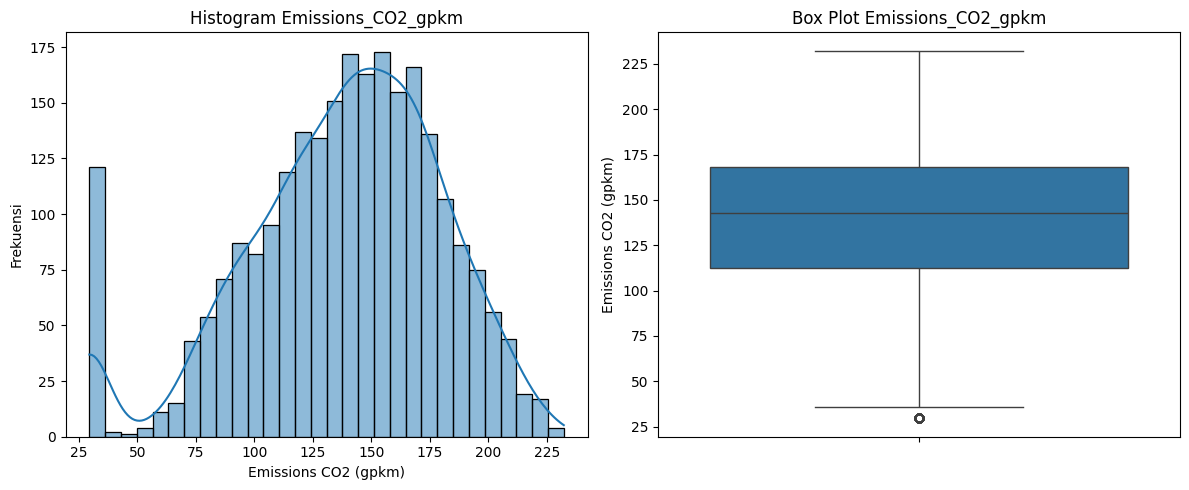

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Emissions_CO2_gpkm'], kde=True, bins=30)
plt.title('Histogram Emissions_CO2_gpkm')
plt.xlabel('Emissions CO2 (gpkm)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Emissions_CO2_gpkm'])
plt.title('Box Plot Emissions_CO2_gpkm')
plt.ylabel('Emissions CO2 (gpkm)')

plt.tight_layout()
plt.show()

### Kolom Engine_Temp_C

Jelaskan kondisi kolom Engine_Temp_C berdasarkan hasil plot distribusi disini.

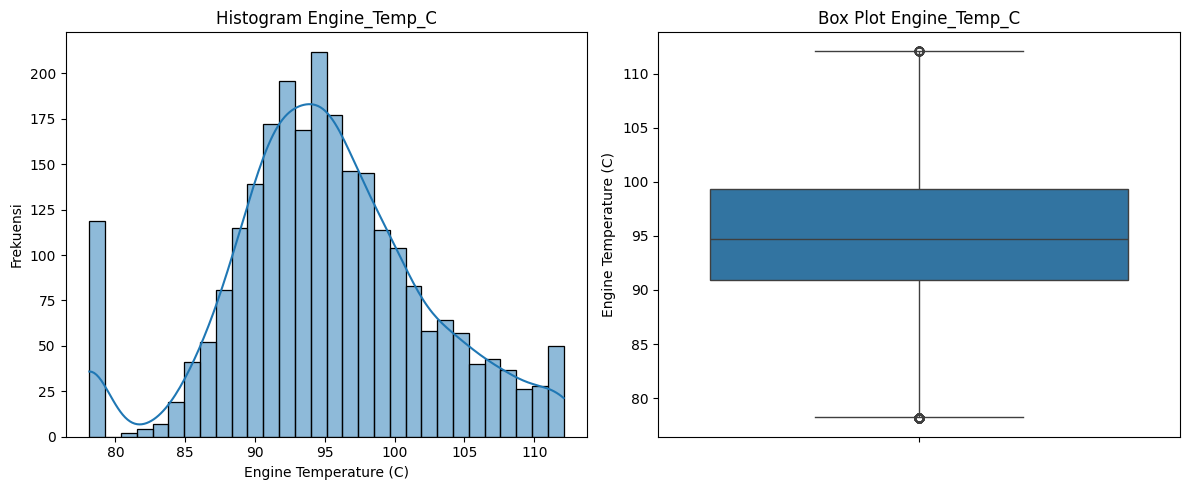

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Engine_Temp_C'], kde=True, bins=30)
plt.title('Histogram Engine_Temp_C')
plt.xlabel('Engine Temperature (C)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Engine_Temp_C'])
plt.title('Box Plot Engine_Temp_C')
plt.ylabel('Engine Temperature (C)')

plt.tight_layout()
plt.show()

### Kolom Engine_Temp_C

Jelaskan kondisi kolom Engine_Temp_C berdasarkan hasil plot distribusi disini.

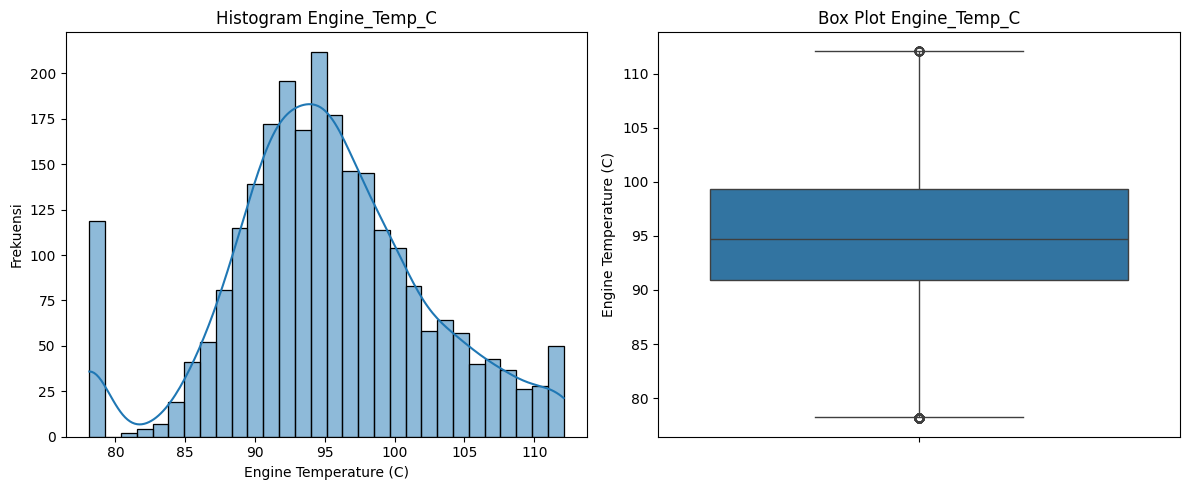

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Engine_Temp_C'], kde=True, bins=30)
plt.title('Histogram Engine_Temp_C')
plt.xlabel('Engine Temperature (C)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Engine_Temp_C'])
plt.title('Box Plot Engine_Temp_C')
plt.ylabel('Engine Temperature (C)')

plt.tight_layout()
plt.show()

### Kolom Engine_Temp_C

Jelaskan kondisi kolom Engine_Temp_C berdasarkan hasil plot distribusi disini.

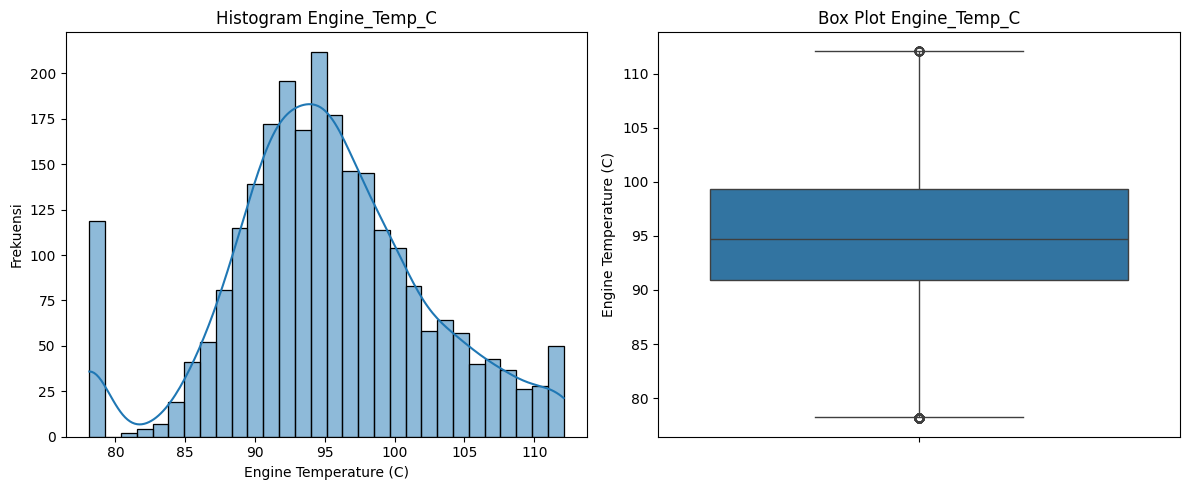

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Engine_Temp_C'], kde=True, bins=30)
plt.title('Histogram Engine_Temp_C')
plt.xlabel('Engine Temperature (C)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Engine_Temp_C'])
plt.title('Box Plot Engine_Temp_C')
plt.ylabel('Engine Temperature (C)')

plt.tight_layout()
plt.show()

### Kolom Engine_Temp_C

Jelaskan kondisi kolom Engine_Temp_C berdasarkan hasil plot distribusi disini.

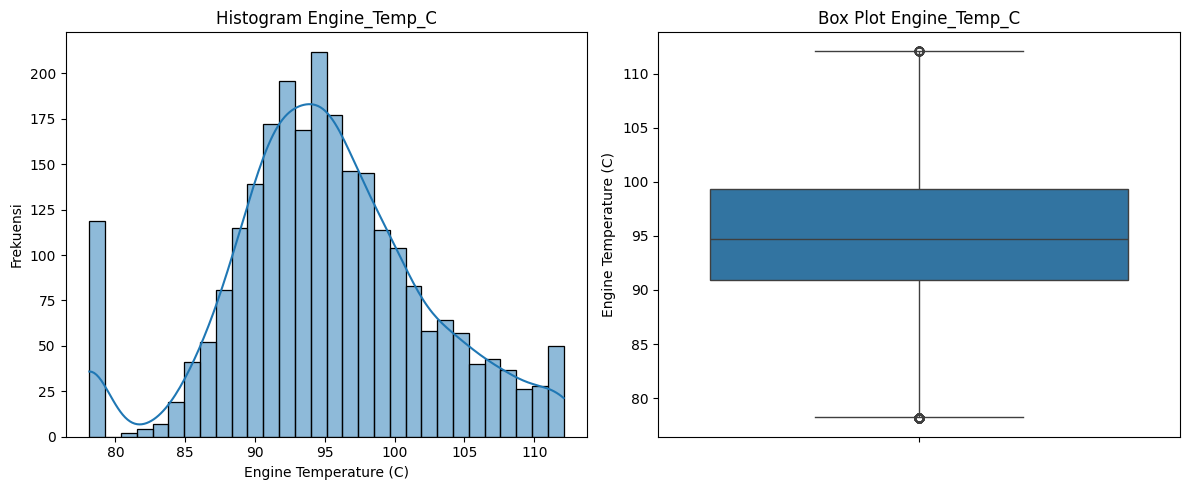

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Engine_Temp_C'], kde=True, bins=30)
plt.title('Histogram Engine_Temp_C')
plt.xlabel('Engine Temperature (C)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Engine_Temp_C'])
plt.title('Box Plot Engine_Temp_C')
plt.ylabel('Engine Temperature (C)')

plt.tight_layout()
plt.show()

### Kolom Engine_Temp_C

Jelaskan kondisi kolom Engine_Temp_C berdasarkan hasil plot distribusi disini.

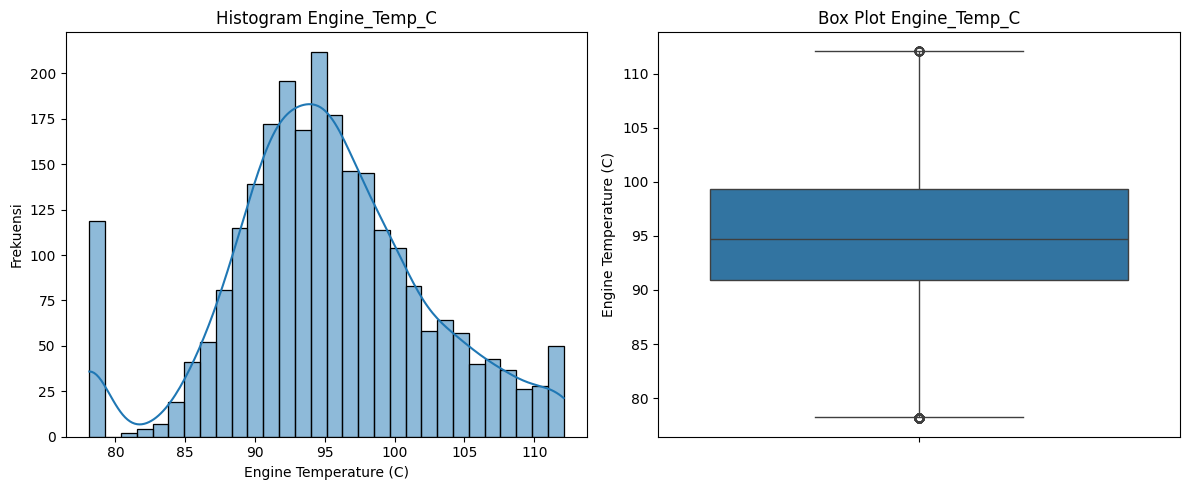

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data_clean['Engine_Temp_C'], kde=True, bins=30)
plt.title('Histogram Engine_Temp_C')
plt.xlabel('Engine Temperature (C)')
plt.ylabel('Frekuensi')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['Engine_Temp_C'])
plt.title('Box Plot Engine_Temp_C')
plt.ylabel('Engine Temperature (C)')

plt.tight_layout()
plt.show()

## Nomor 4
Menentukan distribusi setiap kolom numerik menggunakan hasil visualisasi histogram. Apakah kolom tersebut berdistribusi normal? Jika bukan, terdistribusi seperti apa kolom tersebut?

In [ ]:
# Tulis kode kalian disini

Jelaskan jenis distribusi kolom ... disini.

# Soal Spesifik Dataset

Enam Langkah Testing:

1.  Tentukan Hipotesis nol (H0: θ = θ0), dimana θ bisa berupa μ, σ2, p, atau data lain berdistribusi tertentu (normal, binomial, dsc.).
2. Pilih hipotesis alternatif H1 salah dari dari θ > θ0, θ < θ0, atau θ ≠ θ0.
3. Tentukan tingkat signifikan α.
4. Tentukan uji statistik yang sesuai dan tentukan daerah kritis.
5. Hitung nilai uji statistik dari data sample. Hitung p-value sesuai dengan uji statistik yang digunakan.
6. Ambil keputusan dengan TOLAK H0 jika nilai uji terletak di daerah kritis atau dengan tes signifikan, TOLAK H0 jika p-value lebih kecil dibanding tingkat signifikansi α yang diinginkan

## Nomor 5 : Hipotesis 1 Sampel

1. Pertanyaan 1
2. Pertanyaan 2
3. Pertanyaan 3
4. Pertanyaan 4


### 5.1
Pertanyaan 1

In [ ]:
# Tulis kode kalian disini dengan mengikuti 6 langkah testing.

### 5.2
Pertanyaan 2

In [ ]:
# Tulis kode kalian disini dengan mengikuti 6 langkah testing.

### 5.3
Pertanyaan 3

In [ ]:
# Tulis kode kalian disini dengan mengikuti 6 langkah testing.

### 5.4
Pertanyaan 4

In [ ]:
# Tulis kode kalian disini dengan mengikuti 6 langkah testing.

## Nomor 6 : Hipotesis 2 Sampel
1. Pertanyaan 1
2. Pertanyaan 2
3. Pertanyaan 3
4. Pertanyaan 4

### 6.1
Pertanyaan 1

In [ ]:
# Tulis kode kalian disini dengan mengikuti 6 langkah testing.

### 6.2
Pertanyaan 2

In [ ]:
# Tulis kode kalian disini dengan mengikuti 6 langkah testing.

### 6.3
Pertanyaan 3

In [ ]:
# Tulis kode kalian disini dengan mengikuti 6 langkah testing.

### 6.4
Pertanyaan 4

In [ ]:
# Tulis kode kalian disini dengan mengikuti 6 langkah testing.